### Predict the cost to ship a package based on its properties. 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
packages = pd.read_csv('packages.csv')
packages.head()

,Shipping Cost ($),Length (in),Width (in),Height (in),Weight (lb),Distance (mi)
0,24,36,32,9,18,1079
1,38,41,31,12,18,1797
2,38,34,34,15,24,1722
3,20,32,22,8,8,461
4,24,37,24,14,19,491


### Let's normalize our variables to mean = 0 & SD = 1, which will make our covariance matrix equal the correlation matrix.

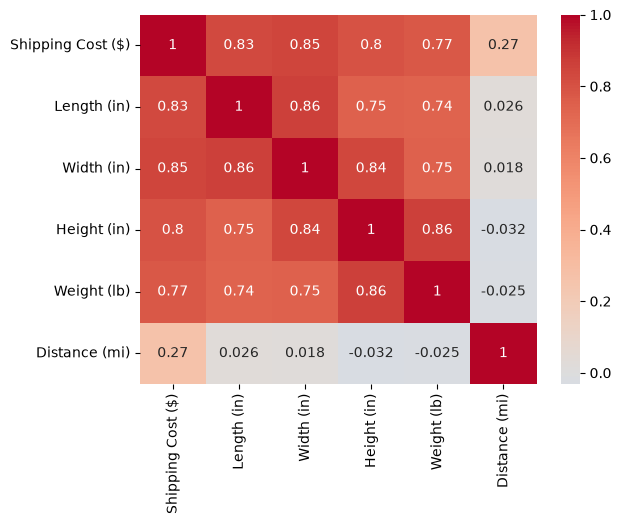

In [4]:
packages_scaled = (packages - packages.mean()) / packages.std()
sns.heatmap(packages_scaled.cov(),
            annot=True,
            fmt="0.2g",
            center=0,
            cmap="coolwarm")
plt.show()

### We will use an eigendecomposition of the covariance matrix to create a new set of dimensions. We can then decide how many of these dimensions to keep based on how much variance is captured by each dimension.

In [6]:
X_packages_scaled = packages_scaled.drop('Shipping Cost ($)', axis=1)

covariance_matrix = X_packages_scaled.cov().values
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

eigenvalues, eigenvectors

(array([3.39821068, 1.00381562, 0.3338863 , 0.08609481, 0.17799259]),
 array([[ 0.49219397,  0.04575099, -0.58937372,  0.39011986,  0.50606033],
        [ 0.50780159,  0.03152634, -0.38635373, -0.59429315, -0.48855918],
        [ 0.5075545 , -0.03825687,  0.38501594,  0.58895092, -0.49580679],
        [ 0.49220305, -0.03337828,  0.59133959, -0.38424744,  0.50920864],
        [-0.00268878,  0.9971636 ,  0.07382155,  0.01062355, -0.00974944]]))

### Let’s take a look at the first two components eigenvector 1 and eigenvector 2 to get a better understanding of what is represented here.

In [7]:
eigenvec1 = eigenvectors[:, 0]
eigenvec2 = eigenvectors[:, 1]

eigenvec1, eigenvec2

(array([ 0.49219397,  0.50780159,  0.5075545 ,  0.49220305, -0.00268878]),
 array([ 0.04575099,  0.03152634, -0.03825687, -0.03337828,  0.9971636 ]))

### We will now use these principal components to create new features. These features will be weighted sums (aka linear combinations) of existing features, using the component weights from the eigenvectors. 
> Principal Component 1  = 0.492 * Length + 0.508 * Width + 0.508 * Height + 0.492 * Weight - 0.003 * Distance

In [8]:
data_array = X_packages_scaled.values
pc1 = data_array.dot(eigenvec1)
X_packages_pca = pd.DataFrame(data=pc1, columns=['PC1'])
X_packages_pca.head()

,PC1
0,1.192513
1,1.688493
2,2.234645
3,-0.290959
4,1.414106


### Implementing PCA using sckit-learn

In [9]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Component loadings (how features contribute to PCs):
                        PC1       PC2
sepal length (cm)  0.521066  0.377418
sepal width (cm)  -0.269347  0.923296
petal length (cm)  0.580413  0.024492
petal width (cm)   0.564857  0.066942


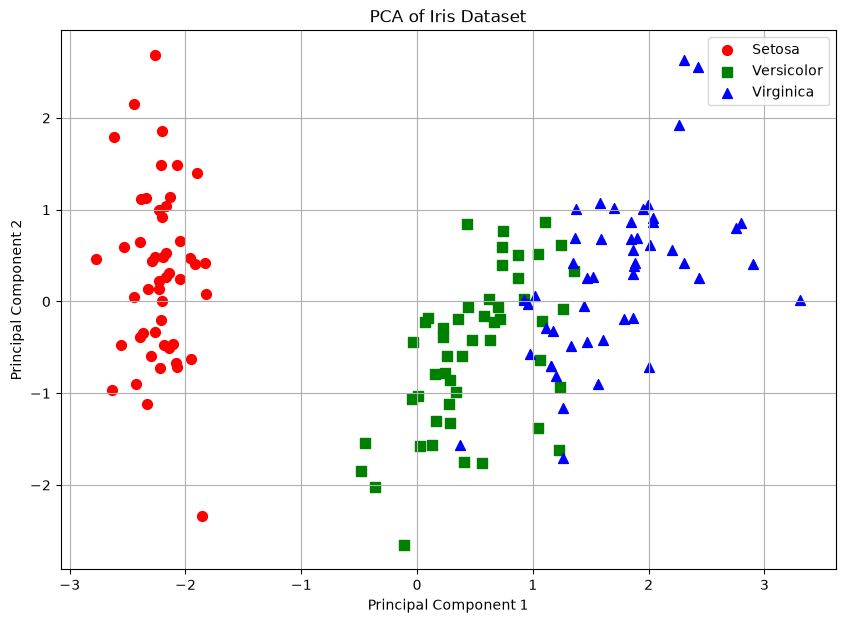

In [10]:
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the data (important preprocessing step for PCA)
X_std = StandardScaler().fit_transform(X)

# Initialize PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA model to data and transform the data
X_pca = pca.fit_transform(X_std)

# Create a DataFrame for easier visualization
pca_df = pd.DataFrame(
    data=X_pca, 
    columns=['Principal Component 1', 'Principal Component 2']
)
pca_df['target'] = y

# Let's examine what the original features contribute to each principal component
# These are the "loadings" - how much each original feature contributes to each PC
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=iris.feature_names
)
print("Component loadings (how features contribute to PCs):")
print(loadings)

# Visualize the transformed data
plt.figure(figsize=(10, 7))
targets = [0, 1, 2]
colors = ['r', 'g', 'b']
markers = ['o', 's', '^']

for target, color, marker in zip(targets, colors, markers):
    indices_to_keep = pca_df['target'] == target
    plt.scatter(
        pca_df.loc[indices_to_keep, 'Principal Component 1'],
        pca_df.loc[indices_to_keep, 'Principal Component 2'],
        c=color, 
        marker=marker,
        s=50
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend(['Setosa', 'Versicolor', 'Virginica'])
plt.grid(True)
plt.show()